# Rubber-Band 🪀
### A stock that closes near its low "snaps back" the next day — true? And can you still cash it?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Still alive?: Decayed](https://img.shields.io/badge/Still_alive%3F-Decayed-8b949e?style=flat-square)

Here's a trader's-lore classic with real teeth. Look at where a stock closes *within* its day — near the high, or near the low. The folk rule (and a genuine academic effect): a bar that closes near its **low** tends to **bounce** the next session. The number that captures it is **Internal Bar Strength**, `IBS = (Close − Low) / (High − Low)` — 0 means closed dead on the low, 1 means dead on the high. Buy the 0s, sell the 1s.

This is the desk's second idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §4.4), and it's a different *kind* of specimen from the last one: not a famous theory that fails, but a humble signal that's **genuinely real** — and then runs into two walls every short-term edge meets. We prove the machinery on a synthetic tape where we bake the bounce in (and a random-walk null where it can't exist), then point it at a basket of real ETFs.

> 📓 **Plain-language layer.** The Newey–West *t*-stat, the break-even-cost maths and the decay curve are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** tape with a *baked-in* bounce, so the real-ETF numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (rubber_band/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from rubber_band import data, ibs, strategy, decompose, extension

# Offline synthetic OHLC: bars with a BAKED-IN IBS->next-day reversal (a close near the low today is
# followed by a positive return tomorrow). The NULL (kappa=0) is a random walk where IBS is noise.
# The real ETF-basket verdict is in ../docs/results.md.
ohlc,  truth = data.synthetic_ohlc(kappa=0.0035, seed=19)     # the reversal tape
ohlc0, _     = data.synthetic_ohlc(kappa=0.0,    seed=19)     # the random-walk null
print(f"{truth.n_bars} synthetic bars | baked reversal kappa={truth.kappa} | null kappa=0")


5040 synthetic bars | baked reversal kappa=0.0035 | null kappa=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does a low close really bounce? | ✅ **Yes — strongly.** A low-IBS day earns far more tomorrow than a high-IBS day (real-ETF Newey–West *t* = **+8.6**). |
| Could you have traded it? | 🚫 **Not for free.** It trades **every day** (~170×/yr turnover); the edge lives inside a few bps of bid-ask. |
| Is it still alive today? | ⚪ **Barely.** It's **decayed** — gross Sharpe **+2.09 → +0.88** across the sample, and the last five years are negative net of 3 bp. |

> Desk shorthand: **Signal `REAL` · Tradability `MIRAGE` · Still alive? `DECAYED`** — a real bounce, competed away.

## 1 · The claim 📣

Stated plainly: **where a bar closes inside its range predicts the next day.** Close near the low (the day's sellers exhausted themselves) and tomorrow tends to recover; close near the high (everyone already piled in) and tomorrow tends to give a little back. It's a short-horizon *mean-reversion* / liquidity-provision story — you're paid for stepping in when others are dumping. On our synthetic tape we baked exactly this in. Sort days into IBS buckets and look at the **next** day's return:

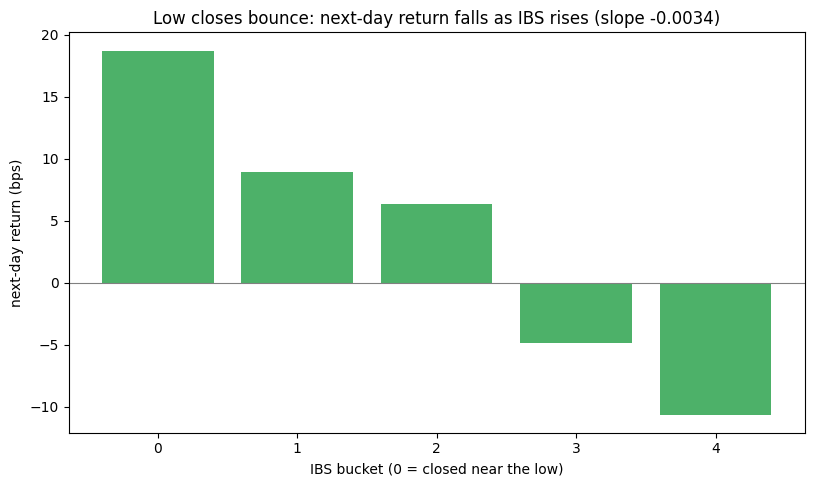

low-IBS minus high-IBS next-day return: +29.4 bps/day


In [2]:
rs = ibs.reversal_strength(ohlc)
t = rs['table']
fig, ax = plt.subplots()
ax.bar(t.index, t['next_ret_bps'].values, color='#2ea44f', alpha=.85)
ax.axhline(0, c='grey', lw=.8); ax.set_xlabel('IBS bucket (0 = closed near the low)')
ax.set_ylabel('next-day return (bps)')
ax.set_title(f"Low closes bounce: next-day return falls as IBS rises (slope {rs['ibs_slope']:+.4f})")
plt.show()
print(f"low-IBS minus high-IBS next-day return: {rs['low_minus_high_bps']:+.1f} bps/day")

A clean downward staircase: the lower the close, the bigger the bounce. *That* is the edge — and it's the same shape on the real ETF tape.

## 2 · So what? 💰

A reliable one-day edge is the holy grail of short-term trading: high hit-rate, fast compounding, market-neutral if you long the lows and short the highs. If a low close really pays tomorrow, you'd trade it across hundreds of instruments and harvest a steady drip. The catch every such edge meets: *one-day* means you **re-trade constantly**, and constant trading meets the bid-ask spread — over and over.

## 3 · How we'd know 🔬

Four checks, up front:

1. **Is the bounce real?** Does a low IBS predict a higher next-day return, with a *t*-stat that says it isn't luck?
2. **Does it survive costs?** The book turns over daily — what's the **break-even** slippage, and does it clear a real spread?
3. **Is it still alive?** Compare the early years to the recent ones — has it decayed?
4. **The null:** on a random-walk tape (no baked bounce) every test must come up empty.

**Mirage line:** the gross edge is real but the **net-of-spread** edge — especially *recently* — is gone.

## 4 · The teardown 🔧

### 4a · The bounce is real — and the null is flat
Same buckets, two synthetic tapes: the baked reversal and the random-walk null. The staircase must appear in one and vanish in the other.

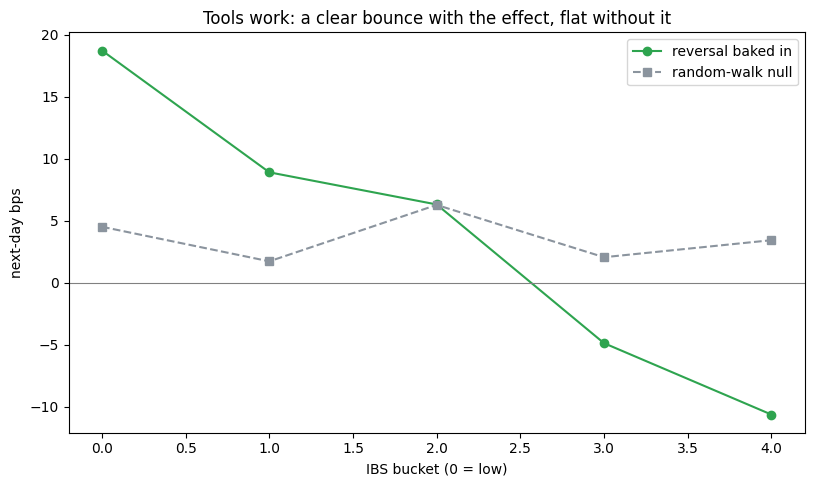

In [3]:
a = ibs.reversal_strength(ohlc)['table']['next_ret_bps']
b = ibs.reversal_strength(ohlc0)['table']['next_ret_bps']
fig, ax = plt.subplots()
ax.plot(a.index, a.values, 'o-', color='#2ea44f', label='reversal baked in')
ax.plot(b.index, b.values, 's--', color='#8b949e', label='random-walk null')
ax.axhline(0, c='grey', lw=.8); ax.set_xlabel('IBS bucket (0 = low)'); ax.set_ylabel('next-day bps'); ax.legend()
ax.set_title('Tools work: a clear bounce with the effect, flat without it')
plt.show()

### 4b · Trade it, before costs
Run the rule — long when yesterday closed near its low (`w = 1 − 2·IBS`), short near the high — and look at the equity curve, gross of costs.

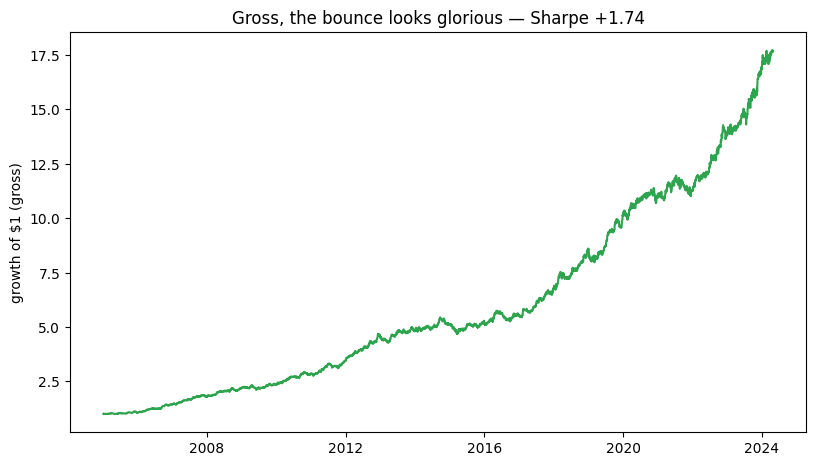

gross Sharpe +1.74, turnover 170x/yr -- note that turnover: it trades essentially every day.


In [4]:
g = strategy.timing_returns(ohlc, cost_bps=0.0)
eq = (1+g).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f')
ax.set_ylabel('growth of $1 (gross)'); ax.set_title(f"Gross, the bounce looks glorious — Sharpe {strategy.summary(g)['sharpe']:+.2f}")
plt.show()
print(f"gross Sharpe {strategy.summary(g)['sharpe']:+.2f}, turnover {strategy.turnover_ann(ohlc):.0f}x/yr "
      f"-- note that turnover: it trades essentially every day.")

### 4c · Now charge the spread
Because it trades daily, even a tiny per-trade cost compounds into a big drag. Watch the Sharpe fall as we charge a few bps per unit traded — the break-even is *low*.

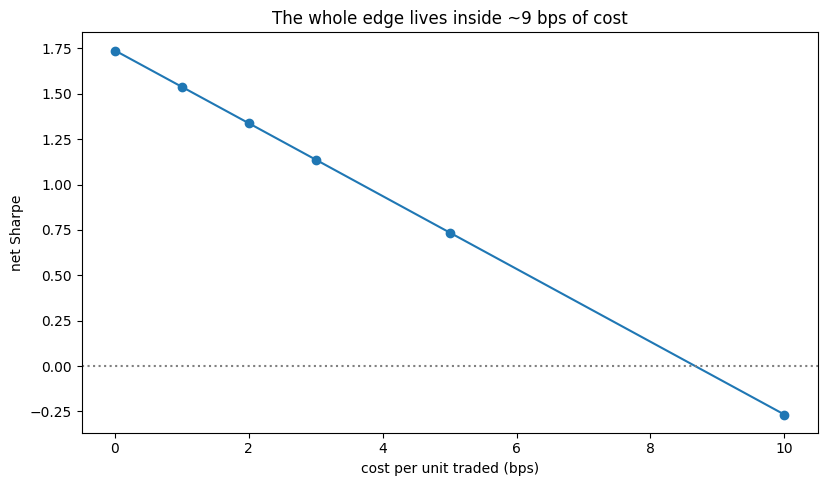

break-even cost 8.7 bps -- a real bid-ask spread is in this range.


In [5]:
sweep = strategy.cost_sweep({'A': ohlc})
be = decompose.breakeven_cost({'A': ohlc})
fig, ax = plt.subplots()
ax.plot(sweep.index, sweep['sharpe'].values, 'o-'); ax.axhline(0, ls=':', c='grey')
ax.set_xlabel('cost per unit traded (bps)'); ax.set_ylabel('net Sharpe')
ax.set_title(f"The whole edge lives inside ~{be['breakeven_bps']:.0f} bps of cost")
plt.show()
print(f"break-even cost {be['breakeven_bps']:.1f} bps -- a real bid-ask spread is in this range.")

### 4d · The real tape — real, but fading
On a basket of 14 real ETFs (quoted from [`../docs/results.md`](../docs/results.md)):

- The bounce is **real**: low-minus-high next-day spread **+20.8 bps/day**, basket gross Sharpe **+1.56**, Newey–West *t* = **+8.6**.
- But it has **decayed**: gross Sharpe **+2.09** in the first half of the sample → **+0.88** in the second → just **+0.40** over the last five years.
- And **net of 3 bp over the last five years it is -0.37** — under water.
- The strongest bounce sits in the *thinnest* ETFs (break-evens like **17.8 bps** for a country fund) — the ones with the *widest* real spreads. The liquid names you could trade cheaply carry a small edge (Sharpe **+0.50**, break-even **3.3 bps**).

## 5 · The verdict 🧾

- **The bounce is real** — *t* = +8.6 on the real basket, clean null on the synthetic.
- **But it's a museum piece** — decayed from Sharpe +2.09 to +0.40, and the recent edge is negative once you pay a realistic spread.

> **Signal `REAL` · Tradability `MIRAGE` · Still alive? `DECAYED`.** A genuine microstructure edge, arbitraged away exactly as a well-known one should be.

## 6 · Could you trade it? 💸

Two walls, both fatal:

- **It lives inside the spread.** ~170×/yr turnover means a few bps per trade compounds into a wall of cost; the basket break-even is **8.1 bps**, and net of a tight 2 bp the recent edge is gone.
- **The edge is where the spread is widest.** The biggest bounce is in thin country ETFs (break-evens of 10–18 bps) whose *real* spreads are just as wide — so the names that pay are the names you can't trade cheaply, and the liquid names barely pay at all.

> Tradability **`MIRAGE`**; "still alive?" **`DECAYED`** — the worked complement ([`../docs/extension.md`](../docs/extension.md)) shows 9 of 14 names clear their own assumed spread full-sample, but the clears sit in the thin country funds where the spread is itself an optimistic guess — and the recent net edge is negative.

## 7 · Going further 🚪

- **The realistic-spread test** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): charge each ETF its *own* plausible spread and count how many clear — 9 of 14 do over the full sample, but mostly the thin country funds whose assumed spread is an optimistic guess, and the recent-window edge is negative by a few bps.
- **Intraday execution.** IBS is a close-to-close signal; entering on the close and exiting on the *open* (or mid) might dodge some cost — does any version survive at a real venue?
- **Single names & longer history.** The bounce is strongest in volatile instruments; does it still live in single stocks pre-2010, and can you date when it died?

PRs welcome — find the execution that keeps a sliver of it, or pin the year the crowd ate it.